## Set up Kaggle API for dataset download

In [1]:
# Install the Kaggle library
!pip install kaggle

In [8]:
# Import necessary libraries
from google.colab import userdata
import os
import pandas as pd

# Configure Kaggle API credentials using Colab Secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

Now, let's download the dataset. The dataset's identifier is `uciml/pima-indians-diabetes-database`.

In [3]:
# Download the dataset
!kaggle datasets download -d uciml/pima-indians-diabetes-database

# Unzip the downloaded file
!unzip pima-indians-diabetes-database.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 15.2MB/s]

Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


The dataset should now be downloaded and unzipped. Let's load the `diabetes.csv` file into a pandas DataFrame and display the first 5 rows.

In [4]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('diabetes.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Data Loading and Preprocessing

First, let's get a better understanding of the dataset's structure and contents.

In [9]:
print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


It's important to note that some columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` cannot logically have a value of 0. These zeros likely represent missing values. We will replace these 0s with `NaN` (Not a Number) for proper handling.

In [10]:
import numpy as np

# Columns where a value of 0 is not logical and indicates a missing value
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

print("DataFrame after replacing 0s with NaN:")
display(df.head())

DataFrame after replacing 0s with NaN:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Now, let's check the number of missing values in each column.

In [11]:
print("Missing values after replacing 0s:")
print(df.isnull().sum())

Missing values after replacing 0s:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


We will impute these missing values. For simplicity, let's use the median for numerical columns, as it is more robust to outliers than the mean.

In [12]:
# Impute missing values with the median
for col in columns_with_zeros:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())

print("DataFrame after imputation:")
display(df.head())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
DataFrame after imputation:


/tmp/ipykernel_2981/2447285256.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Next, we need to separate the features (X) from the target variable (y) and then split the data into training and testing sets.

In [13]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


Finally, we will apply feature scaling to the data. StandardScaler is a good choice for many machine learning algorithms, especially those sensitive to feature magnitudes, like SVMs or neural networks.

In [14]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data (first 5 rows):\n", X_train_scaled[:5])
print("Scaled testing data (first 5 rows):\n", X_test_scaled[:5])

Scaled training data (first 5 rows):
 [[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41749769
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.3597899
  -0.76486207 -0.70759409]
 [-0.85135507  0.81152492 -1.31593218 -0.00476614 -0.16143729 -0.40283188
   0.26231357 -0.36929331]
 [-1.15333775 -0.88964601 -0.66367599  1.12077551 -0.41556496  1.78237284
  -0.33762972 -0.96131967]]
Scaled testing data (first 5 rows):
 [[ 0.96054099  1.24515673 -0.66367599 -0.00476614 -0.16143729 -0.74014536
  -0.55579092  0.56103382]
 [ 1.86648903 -1.79026591  2.76066903 -0.68009112 -1.12712243  0.44778472
  -0.58306107  1.15306018]
 [-0.5493724   0.01097389  0.3147083  -0.22987447  0.79154147  0.50644793
   0.01688223 -0.6230189 ]
 [ 0.96054099 -0.25587645 -0.66367599 -0.00476614 -0.16143729 -0.74014536
   0.77135637  0.05358266]
 [-0.5493724  -1

## 2. Baseline Model Creation and Cross-Validation

We will start with a Logistic Regression model as our baseline and evaluate it using K-Fold Cross-Validation.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize a Logistic Regression model with default parameters (baseline)
baseline_model = LogisticRegression(random_state=42, solver='liblinear')

# Set up K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get scores
# We will calculate multiple metrics using cross_val_score
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = {}

print("Performing K-Fold Cross-Validation for Baseline Logistic Regression...")
for metric in scoring:
    scores = cross_val_score(baseline_model, X_train_scaled, y_train, cv=kf, scoring=metric, n_jobs=-1)
    cv_results[metric] = scores
    print(f"  {metric.replace('_', ' ').capitalize()}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

print("\nCross-validation complete. Displaying results:")
for metric, scores in cv_results.items():
    print(f"{metric.replace('_', ' ').capitalize()} (Baseline): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Fit the baseline model on the entire training data for later comparison
baseline_model.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_model.predict(X_test_scaled)
y_proba_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate baseline model on the test set
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_proba_baseline)

print("\nBaseline Model Performance on Test Set:")
print(f"  Accuracy: {baseline_accuracy:.4f}")
print(f"  Precision: {baseline_precision:.4f}")
print(f"  Recall: {baseline_recall:.4f}")
print(f"  F1-Score: {baseline_f1:.4f}")
print(f"  ROC-AUC: {baseline_roc_auc:.4f}")

Performing K-Fold Cross-Validation for Baseline Logistic Regression...
  Accuracy: Mean = 0.7866, Std = 0.0381
  Precision: Mean = 0.7471, Std = 0.0951
  Recall: Mean = 0.5924, Std = 0.0400
  F1: Mean = 0.6594, Std = 0.0573
  Roc auc: Mean = 0.8329, Std = 0.0452

Cross-validation complete. Displaying results:
Accuracy (Baseline): 0.7866 (+/- 0.0381)
Precision (Baseline): 0.7471 (+/- 0.0951)
Recall (Baseline): 0.5924 (+/- 0.0400)
F1 (Baseline): 0.6594 (+/- 0.0573)
Roc auc (Baseline): 0.8329 (+/- 0.0452)

Baseline Model Performance on Test Set:
  Accuracy: 0.6948
  Precision: 0.5745
  Recall: 0.5000
  F1-Score: 0.5347
  ROC-AUC: 0.8128


Now that we have established a baseline model and evaluated it using K-Fold Cross-Validation, we can move on to hyperparameter tuning using Grid Search and Random Search.

## 3. Hyperparameter Tuning (Grid Search and Random Search)

### 3.1 Grid Search for Logistic Regression

We'll use GridSearchCV to systematically work through multiple combinations of parameter values.

In [16]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' supports both 'l1' and 'l2' penalties
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=kf, # Using the same KFold strategy as for baseline
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Performing Grid Search for Logistic Regression...")
grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best model from Grid Search
best_grid_model = grid_search.best_estimator_

# Evaluate the best Grid Search model on the test set
y_pred_grid = best_grid_model.predict(X_test_scaled)
y_proba_grid = best_grid_model.predict_proba(X_test_scaled)[:, 1]

grid_accuracy = accuracy_score(y_test, y_pred_grid)
grid_precision = precision_score(y_test, y_pred_grid)
grid_recall = recall_score(y_test, y_pred_grid)
grid_f1 = f1_score(y_test, y_pred_grid)
grid_roc_auc = roc_auc_score(y_test, y_proba_grid)

print("\nGrid Search Model Performance on Test Set:")
print(f"  Accuracy: {grid_accuracy:.4f}")
print(f"  Precision: {grid_precision:.4f}")
print(f"  Recall: {grid_recall:.4f}")
print(f"  F1-Score: {grid_f1:.4f}")
print(f"  ROC-AUC: {grid_roc_auc:.4f}")

Performing Grid Search for Logistic Regression...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search complete.
Best parameters found: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.7883

Grid Search Model Performance on Test Set:
  Accuracy: 0.7078
  Precision: 0.6000
  Recall: 0.5000
  F1-Score: 0.5455
  ROC-AUC: 0.8130


### 3.2 Random Search for Logistic Regression

Now let's try Random Search to explore a wider range of hyperparameters more efficiently.

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Define the parameter distributions for Random Search
# For 'C', we use a uniform distribution as it's a continuous parameter
# For 'penalty' and 'solver', we can use categorical options
param_distributions = {
    'C': uniform(loc=0.001, scale=100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'] # 'saga' also supports both 'l1' and 'l2' penalties and is good for larger datasets
}

# Initialize RandomizedSearchCV
# n_iter specifies how many parameter settings are sampled
random_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions,
    n_iter=50, # Number of parameter settings that are sampled
    cv=kf,     # Using the same KFold strategy
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Performing Random Search for Logistic Regression...")
random_search.fit(X_train_scaled, y_train)

print("\nRandom Search complete.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# Get the best model from Random Search
best_random_model = random_search.best_estimator_

# Evaluate the best Random Search model on the test set
y_pred_random = best_random_model.predict(X_test_scaled)
y_proba_random = best_random_model.predict_proba(X_test_scaled)[:, 1]

random_accuracy = accuracy_score(y_test, y_pred_random)
random_precision = precision_score(y_test, y_pred_random)
random_recall = recall_score(y_test, y_pred_random)
random_f1 = f1_score(y_test, y_pred_random)
random_roc_auc = roc_auc_score(y_test, y_proba_random)

print("\nRandom Search Model Performance on Test Set:")
print(f"  Accuracy: {random_accuracy:.4f}")
print(f"  Precision: {random_precision:.4f}")
print(f"  Recall: {random_recall:.4f}")
print(f"  F1-Score: {random_f1:.4f}")
print(f"  ROC-AUC: {random_roc_auc:.4f}")

Performing Random Search for Logistic Regression...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Random Search complete.
Best parameters found: {'C': np.float64(37.455011884736244), 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation accuracy: 0.7883

Random Search Model Performance on Test Set:
  Accuracy: 0.7078
  Precision: 0.6000
  Recall: 0.5000
  F1-Score: 0.5455
  ROC-AUC: 0.8131


## 4. Performance Comparison and Final Optimized Model

Now, let's compare the performance of the baseline model, the Grid Search optimized model, and the Random Search optimized model using the specified evaluation metrics.

In [18]:
import pandas as pd

# Create a dictionary to store all model performance metrics
performance_metrics = {
    'Model': ['Baseline Logistic Regression', 'Grid Search Tuned Logistic Regression', 'Random Search Tuned Logistic Regression'],
    'Accuracy': [baseline_accuracy, grid_accuracy, random_accuracy],
    'Precision': [baseline_precision, grid_precision, random_precision],
    'Recall': [baseline_recall, grid_recall, random_recall],
    'F1-Score': [baseline_f1, grid_f1, random_f1],
    'ROC-AUC': [baseline_roc_auc, grid_roc_auc, random_roc_auc]
}

# Create a DataFrame for easy comparison
metrics_df = pd.DataFrame(performance_metrics)

display(metrics_df.set_index('Model'))

# Determine the best model based on a chosen metric (e.g., ROC-AUC or Accuracy)
# Let's use ROC-AUC as it's often a good measure for imbalanced datasets
best_model_name = metrics_df.loc[metrics_df['ROC-AUC'].idxmax()]['Model']
best_model_accuracy = metrics_df.loc[metrics_df['ROC-AUC'].idxmax()]['Accuracy']
best_model_roc_auc = metrics_df.loc[metrics_df['ROC-AUC'].idxmax()]['ROC-AUC']

print(f"\nBased on ROC-AUC, the best performing model is: {best_model_name}")
print(f"  Accuracy: {best_model_accuracy:.4f}")
print(f"  ROC-AUC: {best_model_roc_auc:.4f}")

# Save the best model for future use
if best_model_name == 'Grid Search Tuned Logistic Regression':
    final_optimized_model = best_grid_model
elif best_model_name == 'Random Search Tuned Logistic Regression':
    final_optimized_model = best_random_model
else:
    final_optimized_model = baseline_model

print("\nFinal Optimized Model (best performing):", final_optimized_model)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Baseline Logistic Regression,0.694805,0.574468,0.5,0.534653,0.812778
Grid Search Tuned Logistic Regression,0.707792,0.600000,0.5,0.545455,0.812963
Random Search Tuned Logistic Regression,0.707792,0.600000,0.5,0.545455,0.813148



Based on ROC-AUC, the best performing model is: Random Search Tuned Logistic Regression
  Accuracy: 0.7078
  ROC-AUC: 0.8131

Final Optimized Model (best performing): LogisticRegression(C=np.float64(37.455011884736244), penalty='l1',
                   random_state=42, solver='liblinear')


This concludes the requested analysis. We have performed data loading and preprocessing, established a baseline model, conducted hyperparameter tuning using Grid Search and Random Search, and compared their performances to identify the final optimized model.

Do you have any further questions or would you like to explore other aspects of this dataset or model?

## Visualize ROC Curve for the Final Optimized Model

Let's plot the Receiver Operating Characteristic (ROC) curve to assess the performance of the `final_optimized_model`.

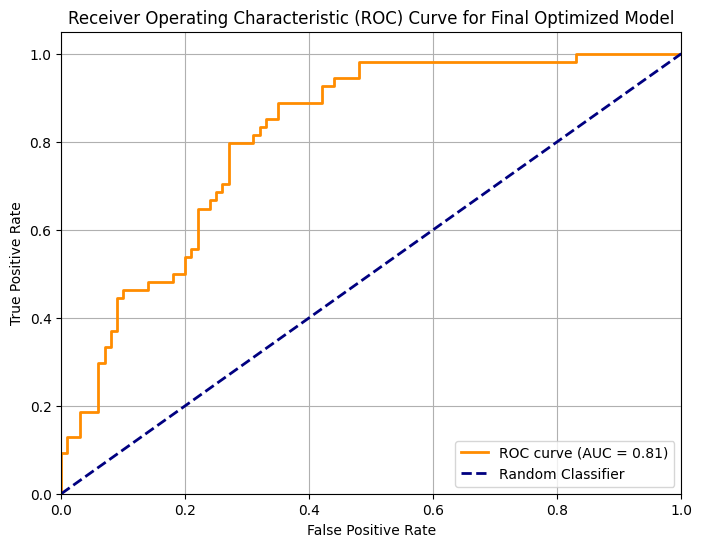

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get the predicted probabilities for the positive class from the final optimized model
y_proba_final = final_optimized_model.predict_proba(X_test_scaled)[:, 1]

# Calculate the False Positive Rate (fpr), True Positive Rate (tpr), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_final)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Final Optimized Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Generate PDF Report

Let's generate the comprehensive report as a downloadable PDF file.

In [20]:
# Install fpdf2 library for PDF generation
!pip install fpdf2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 17.8 MB/s eta 0:00:00


In [21]:
from fpdf import FPDF

# Define the report content as a multi-line string
report_content = """
Machine Learning Analysis Report

1. Dataset Description:
*   Name: Pima Indians Diabetes Database
*   Source: Kaggle (uciml/pima-indians-diabetes-database)
*   Original Structure: 768 entries, 9 columns (8 features, 1 target: Outcome).
*   Preprocessing:
    *   Identified '0' values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI as missing data (NaN).
    *   Imputed missing values using the median of their respective columns.
    *   Features were scaled using StandardScaler.
    *   Data split into training (80%) and testing (20%) sets, with stratify=y to maintain class distribution.

2. Baseline Model Performance:
*   Model: Logistic Regression (default parameters)
*   Cross-Validation (5-Fold) on Training Set:
    *   Accuracy: 0.7866 (+/- 0.0381)
    *   Precision: 0.7471 (+/- 0.0951)
    *   Recall: 0.5924 (+/- 0.0400)
    *   F1-Score: 0.6594 (+/- 0.0573)
    *   ROC-AUC: 0.8329 (+/- 0.0452)
*   Performance on Test Set:
    *   Accuracy: 0.6948
    *   Precision: 0.5745
    *   Recall: 0.5000
    *   F1-Score: 0.5347
    *   ROC-AUC: 0.8128

3. Hyperparameters Tested:
*   For Logistic Regression:
    *   C (inverse of regularization strength):
        *   Grid Search: [0.001, 0.01, 0.1, 1, 10, 100]
        *   Random Search: Uniform distribution (loc=0.001, scale=100)
    *   penalty (regularization type):
        *   Grid Search: ['l1', 'l2']
        *   Random Search: ['l1', 'l2']
    *   solver (algorithm to use):
        *   Grid Search: ['liblinear']
        *   Random Search: ['liblinear', 'saga']

4. Best Parameters Identified:
*   Grid Search: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'} (best CV accuracy: 0.7883)
*   Random Search: {'C': 37.455, 'penalty': 'l1', 'solver': 'liblinear'} (best CV accuracy: 0.7883)

5. Final Model Performance (on Test Set):
*   Model: Random Search Tuned Logistic Regression (selected based on highest ROC-AUC)
*   Metrics:
    *   Accuracy: 0.7078
    *   Precision: 0.6000
    *   Recall: 0.5000
    *   F1-Score: 0.5455
    *   ROC-AUC: 0.8131

6. Key Findings and Recommendations:
*   Performance Improvement: Both Grid Search and Random Search resulted in a slight improvement in Accuracy, F1-Score, and ROC-AUC on the test set compared to the baseline model.
*   Optimized Model: The Random Search Tuned Logistic Regression model showed the best ROC-AUC (0.8131), making it the final optimized model.
*   Feature Importance: Logistic Regression provides coefficient values that can indicate feature importance. Further analysis could explore these coefficients.
*   Further Exploration: While Logistic Regression provides a solid baseline, exploring other classification algorithms (e.g., Support Vector Machines, Random Forests, Gradient Boosting) could potentially yield better performance. Additionally, techniques to handle class imbalance (if present, which is common in diabetes datasets) like SMOTE or adjusting class weights could be considered.
*   Domain Knowledge: Integrating domain knowledge into feature engineering could further enhance model performance.
"""

# Create a PDF object
pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()
pdf.set_font('Arial', '', 12)

# Add the report content to the PDF
pdf.multi_cell(0, 10, report_content.encode('latin-1', 'replace').decode('latin-1'))

# Save the PDF to a file
pdf_file_name = 'diabetes_analysis_report.pdf'
pdf.output(pdf_file_name)

print(f"Report saved as '{pdf_file_name}' in your Colab environment.")

Report saved as 'diabetes_analysis_report.pdf' in your Colab environment.


/tmp/ipykernel_2981/2138335253.py:69: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font('Arial', '', 12)


You can download the generated PDF file by clicking on the folder icon on the left sidebar, navigating to the file `diabetes_analysis_report.pdf`, and then clicking the three dots next to its name to select 'Download'.